# Taller 03: Coloreado de Grafos con BT-FC-DO
Implementación de Backtracking con Forward Checking y Dynamic Ordering
para resolver problemas de coloreado de grafos.

## Cómo se resuelve el problema

Este notebook implementa una solución basada en búsqueda con backtracking, utilizando forward checking y dynamic ordering para resolver el problema de coloreado de grafos. La idea principal es asignar un color a cada nodo evitando que dos nodos adyacentes compartan el mismo color, mientras se reduce el dominio de posibles colores de los vecinos para evitar ramificaciones innecesarias. El flujo general del notebook incluye: definir la clase del grafo, generar grafos aleatorios, leer una matriz desde un archivo `.txt`, resolver el problema con BT-FC-DO y visualizar el resultado final.

## Imports necesarios

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from typing import List, Tuple, Optional, Dict, Set
import time

## Clase general del grafo

In [2]:
class GraphColoringSolver:
    """
    Clase objeto general para crear el grafo y resolver el problema de coloreado de grafos
    """

    def __init__(self, adjacency_matrix: np.ndarray, num_colors: int):
        self.adj_matrix = adjacency_matrix
        self.n_nodes = adjacency_matrix.shape[0]
        self.num_colors = num_colors
        self.colors = list(range(num_colors))
        self.domains = [set(self.colors) for _ in range(self.n_nodes)]
        self.assignment = [-1] * self.n_nodes
        self.nodes_visited = 0
        self.backtracks = 0

    def get_neighbors(self, node: int) -> List[int]:
        # Obtiene los vecinos de un nodo
        neighbors = []
        for i in range(self.n_nodes):
            if self.adj_matrix[node][i] == 1:
                neighbors.append(i)
        return neighbors

    def forward_checking(self, node: int, color: int) -> Tuple[bool, Dict[int, Set[int]]]:
        neighbors = self.get_neighbors(node)
        domain_changes = {}

        for neighbor in neighbors:
            if self.assignment[neighbor] == -1:
                if color in self.domains[neighbor]:
                    if neighbor not in domain_changes:
                        domain_changes[neighbor] = self.domains[neighbor].copy()
                    self.domains[neighbor].remove(color)
                    if len(self.domains[neighbor]) == 0:
                        self.restore_domains(domain_changes)
                        return False, domain_changes

        return True, domain_changes

    def restore_domains(self, domain_changes: Dict[int, Set[int]]):
        for node, domain in domain_changes.items():
            self.domains[node] = domain.copy()

    def select_variable_mrv(self) -> Optional[int]:
        unassigned = [i for i in range(self.n_nodes) if self.assignment[i] == -1]

        if not unassigned:
            return None
        
        def sort_key(node):
            domain_size = len(self.domains[node])
            degree = len(self.get_neighbors(node))
            return (domain_size, -degree)
        return min(unassigned, key=sort_key)

    def order_domain_values(self, node: int) -> List[int]:
        
        def count_constraints(color):
            count = 0
            for neighbor in self.get_neighbors(node):
                if self.assignment[neighbor] == -1 and color in self.domains[neighbor]:
                    count += 1
            return count
        
        return sorted(self.domains[node], key=count_constraints)

    def is_valid_assignment(self, node: int, color: int) -> bool:
        for neighbor in self.get_neighbors(node):
            if self.assignment[neighbor] == color:
                return False
        return True

    def backtrack(self) -> bool:
        self.nodes_visited += 1

        node = self.select_variable_mrv()

        if node is None:
            return True
        
        ordered_colors = self.order_domain_values(node)

        for color in ordered_colors:
            if self.is_valid_assignment(node, color):
                self.assignment[node] = color
                original_domain = self.domains[node].copy()
                self.domains[node] = {color}

                fc_success, domain_changes = self.forward_checking(node, color)

                if fc_success:
                    if self.backtrack():
                        return True
                    
                self.backtracks += 1
                self.assignment[node] = -1
                self.domains[node] = original_domain
                self.restore_domains(domain_changes)

        return False

    def solve(self) -> bool:
        self.nodes_visited = 0
        self.backtracks = 0
        return self.backtrack()

    def get_solution(self) -> List[int]:
        return self.assignment.copy()


## Generar Grafo aleatorio

In [3]:
def generate_random_graph(n_nodes: int, density: float = 0.5, seed: int = None) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)

    adj_matrix = np.zeros((n_nodes, n_nodes), dtype=int)

    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            if np.random.random() < density:
                adj_matrix[i][j] = 1
                adj_matrix[j][i] = 1

    return adj_matrix

## Leer Grafo de un archivo
La lectura del archivo de texto se hace con `numpy.loadtxt`, que interpreta el contenido como una matriz numérica. En el caso del grafo, el archivo debe contener la matriz de adyacencia del grafo, donde cada fila y cada columna representan un nodo y cada valor es `1` si hay conexión entre nodos o `0` si no la hay. Si el archivo está organizado en filas y columnas con espacios o saltos de línea, `loadtxt` lo convierte automáticamente en un arreglo de NumPy para que el algoritmo pueda trabajar con él.

In [8]:
def read_graph_from_file(filename: str) -> np.ndarray:
    adj_matrix = np.loadtxt(filename, dtype=int)
    return adj_matrix

## Dibujar el Grafo

In [5]:
def visualize_graph(adj_matrix: np.ndarray, coloring: List[int], title: str = "Coloreado de Grafos"):
    n_nodes = adj_matrix.shape[0]
    G = nx.Graph()

    # Agregar nodos
    for i in range(n_nodes):
        G.add_node(i)

    # Agregar aristas
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            if adj_matrix[i][j] == 1:
                G.add_edge(i, j)

    # Crear layout
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    # Paleta de colores
    color_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4',
                     '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F',
                     '#BB8FCE', '#85C1E9', '#F8C471', '#82E0AA']

    # Asignar colores a los nodos
    node_colors = []
    for color in coloring:
        if color != -1:
            node_colors.append(color_palette[color % len(color_palette)])
        else:
            node_colors.append('#CCCCCC')

    fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)

    # Dibujar el grafo
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=500,
            font_size=12,
            font_weight='bold',
            with_labels=True,
            edge_color='gray',
            width=1.5,
            alpha=0.8,
            ax=ax)

    # Crear leyenda
    legend_elements = []
    for i, color in enumerate(color_palette):
        if i < len(set(coloring)):
            from matplotlib.patches import Patch
            legend_elements.append(Patch(facecolor=color, label=f'Color {i+1}'))

    if legend_elements:
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.show()


## Ejemplo 1: Grafo aleatorio pequeño


Grafo aleatorio con 6 nodos y densidad 0.4
Matriz de adyacencia:
[[0 1 0 0 0 1]
 [1 0 1 1 0 0]
 [0 1 0 0 1 0]
 [0 1 0 0 0 1]
 [0 0 1 0 0 1]
 [1 0 0 1 1 0]]
Solución encontrada en 0.0000 segundos
Nodos visitados: 7
Backtracks: 0
Asignación de colores: [1, 0, 1, 1, 2, 0]


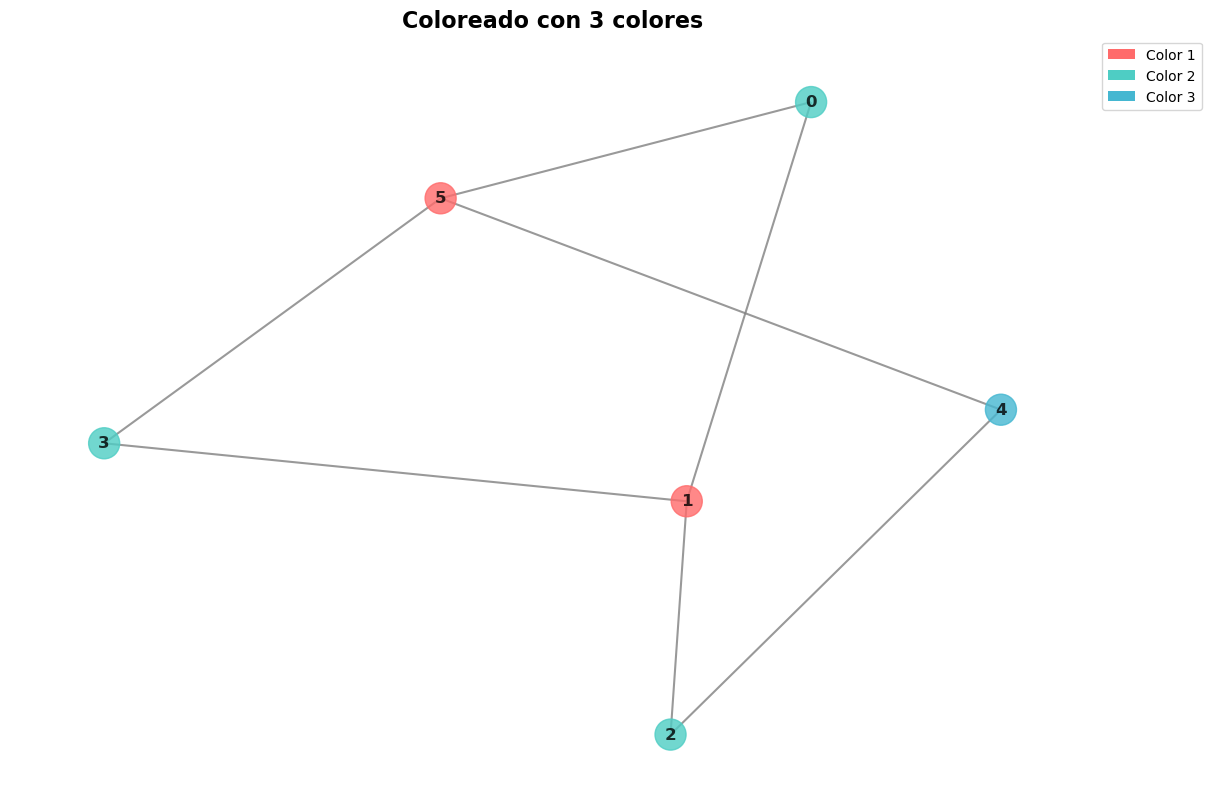

In [6]:
# Generar grafo aleatorio
n_nodes = 6
density = 0.4
adj_matrix = generate_random_graph(n_nodes, density, seed=42)
num_colors = 3

print(f"Grafo aleatorio con {n_nodes} nodos y densidad {density}")
print("Matriz de adyacencia:")
print(adj_matrix)

# Resolver problema de coloreado
solver = GraphColoringSolver(adj_matrix, num_colors)
start_time = time.time()
success = solver.solve()
end_time = time.time()

if success:
    coloring = solver.get_solution()
    print(f"Solución encontrada en {end_time - start_time:.4f} segundos")
    print(f"Nodos visitados: {solver.nodes_visited}")
    print(f"Backtracks: {solver.backtracks}")
    print(f"Asignación de colores: {coloring}")

    # Visualizar
    visualize_graph(adj_matrix, coloring, f"Coloreado con {num_colors} colores")
else:
    print(f"\n✗ No se encontró solución con {num_colors} colores")

## Guardar y cargar grafos desde archivo


Grafo cargado desde 'grafo.txt':
[[0 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 0 0]
 [1 0 0 1 1 0 1 1]
 [1 0 1 0 0 0 0 0]
 [0 1 1 0 0 0 0 0]
 [0 1 0 0 0 0 1 1]
 [0 0 1 0 0 1 0 1]
 [0 0 1 0 0 1 1 0]]
Solución encontrada para el grafo cargado
Asignación de colores: [1, 1, 0, 2, 2, 0, 1, 2]


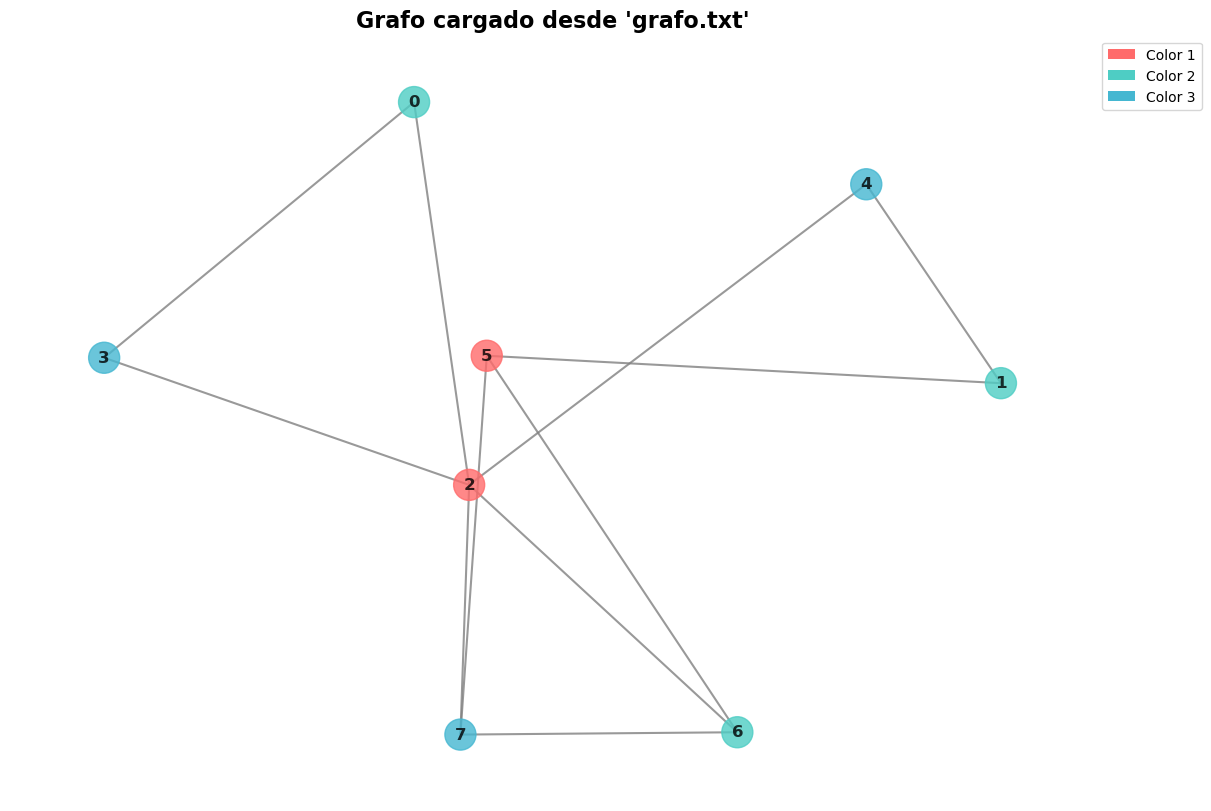

In [7]:
# Cargar desde archivo
filename = 'grafo.txt'
loaded_graph = read_graph_from_file(filename)
print(f"\nGrafo cargado desde '{filename}':")
print(loaded_graph)

# Resolver el grafo cargado
solver_loaded = GraphColoringSolver(loaded_graph, 3)
success_loaded = solver_loaded.solve()

if success_loaded:
    coloring_loaded = solver_loaded.get_solution()
    print(f"Solución encontrada para el grafo cargado")
    print(f"Asignación de colores: {coloring_loaded}")
    visualize_graph(loaded_graph, coloring_loaded, f"Grafo cargado desde '{filename}'")
else:
    print(f"\nNo se encontró solución con 3 colores")